# 04 — The model, built up one block at a time

This notebook is the walkthrough for `ml/model.py` and `ml/train.py`. It
builds the architecture in stages, shows the tensor shape after each one, and
explains what each stage is *for* in microstructure terms rather than in
tensor terms.

Then it does the three things that turn an architecture into a result: prove
the model can learn at all, train it honestly, and put the number next to
baselines that make it meaningful.

**Roadmap**

1. The convolutional front end: three deliberate ways to collapse 40 columns.
2. Inception-lite: not choosing a temporal scale.
3. The TCN head, and the receptive field that justifies it.
4. Why a TCN and not an LSTM; why not a transformer.
5. Overfitting one batch on purpose.
6. The data, the splits, and where early stopping looks.
7. Baselines — including one that is uncomfortably good.
8. Training curves and the honest results table.

In [1]:
import glob
import json
import sys
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "ml").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from ml.model import ModelConfig, build_model

model = build_model(seed=0)
model.eval()
print(f"parameters      : {model.parameter_count():,}")
print(f"receptive field : {model.receptive_field()} of {model.config.window_length} timesteps")
print(f"input           : [batch, {model.config.window_length}, {model.config.feature_count}]")
print(f"output          : [batch, {model.config.num_classes}]  (down / flat / up logits)")

parameters      : 319,715
receptive field : 83 of 100 timesteps
input           : [batch, 100, 40]
output          : [batch, 3]  (down / flat / up logits)


### A deliberately small model

319,715 parameters. That is a design commitment, not an accident: Stage 6 has
to distil this into something smaller, and Stage 7 has to reimplement its
forward pass by hand in C++. A model that cannot be held in your head cannot
be hand-rolled, and `tests/test_model.py` fails the build if the count drifts
outside 250K–400K.

The receptive field of 83 timesteps matters for a different reason, covered in
section 3.

## 1. The convolutional front end

The input is `[100, 40]`: 100 snapshots, each 40 numbers laid out as

```
[ bid_price_1, bid_size_1, ask_price_1, ask_size_1,   <- level 1
  bid_price_2, bid_size_2, ask_price_2, ask_size_2,   <- level 2
  ... ten levels ... ]
```

The front end collapses that 40-wide axis to 1 in **three deliberate steps**,
each of which is a microstructure statement:

| Step | Kernel | Width | What it fuses | Why that is a sensible thing to compute |
|---|---|---|---|---|
| 1 | `(1,2)` stride 2 | 40 → 20 | price with size | "how much is resting here, and where" — a level is a *pair*, and neither half means much alone |
| 2 | `(1,2)` stride 2 | 20 → 10 | bid side with ask side | per-level **imbalance**, the single most predictive cheap feature in microstructure |
| 3 | `(1,10)` | 10 → 1 | the ten levels | the shape of the whole visible book — is depth stacked at the touch or far out? |

Between each, two causal convolutions of width 4 look along *time* at that
width. Mixing levels and mixing time are different operations, and separating
them is what makes each layer explainable.

In [2]:
hidden = torch.randn(4, 100, 40).unsqueeze(1)
print(f"{'stage':<26} {'shape':<24} parameters")
print(f"{'input':<26} {str(tuple(hidden.shape)):<24} -")
with torch.no_grad():
    for name in ("fuse_price_and_size", "fuse_sides", "fuse_levels"):
        stage = getattr(model, name)
        hidden = stage(hidden)
        count = sum(p.numel() for p in stage.parameters())
        print(f"{name:<26} {str(tuple(hidden.shape)):<24} {count:>9,}")
    after_inception = model.inception(hidden)
    inception_params = sum(p.numel() for p in model.inception.parameters())
    print(f"{'inception':<26} {str(tuple(after_inception.shape)):<24} {inception_params:>9,}")

stage                      shape                    parameters
input                      (4, 1, 100, 40)          -
fuse_price_and_size        (4, 32, 100, 20)             8,544
fuse_sides                 (4, 32, 100, 10)            10,528
fuse_levels                (4, 32, 100, 1)             18,720
inception                  (4, 192, 100, 1)            39,616


### 40 → 20 → 10 → 1, exactly as designed

The feature axis collapses on schedule and the time axis stays at 100
throughout — causal padding preserves length, which matters because the model
reads out the *last* timestep and a shrinking axis would silently change which
timestep that is.

Notice the channel count jumps to 192 at the inception block: three branches
of 64 concatenated. That is the widest point in the network, and it is
immediately projected back down to 96 before the TCN.

## 2. Inception-lite: not choosing a temporal scale

The front end's temporal kernels are all width 4. But microstructure does not
have one timescale: queue depletion at the touch resolves over a handful of
events, while a directional drift plays out over tens.

Rather than tuning a single kernel width, the inception block runs three
views in parallel — kernel 3, kernel 5, and a max-pooled branch — and
concatenates them, letting the network learn how much of each to use.

Rejected alternative: one wide kernel. Same receptive field, more parameters,
and no ability to weight the scales differently.

In [3]:
branches = {
    "kernel 3 (fast)": ["reduce_three", "conv_three"],
    "kernel 5 (slower)": ["reduce_five", "conv_five"],
    "max-pool (robust)": ["pool_project"],
}
for label, parts in branches.items():
    count = sum(sum(p.numel() for p in getattr(model.inception, part).parameters()) for part in parts)
    print(f"  {label:<20} {count:>8,} parameters")
print(f"  {'concatenated':<20} {model.config.inception_channels * 3:>8} channels -> projected to "
      f"{model.config.tcn_channels}")

  kernel 3 (fast)        14,464 parameters
  kernel 5 (slower)      22,656 parameters
  max-pool (robust)       2,112 parameters
  concatenated              192 channels -> projected to 96


### Three views, one tensor

The max-pool branch is worth a word: it has no temporal convolution at all,
just a pooled summary projected to the same width. It gives the block a path
that is robust to exactly *when* something happened within the last few
events — useful when the signal is "a big trade landed recently" rather than
"a big trade landed two ticks ago".

## 3. The TCN head and its receptive field

Four residual blocks of dilated causal convolutions, dilations 1, 2, 4, 8. Each
block is two convolutions plus a skip connection.

Dilation is how a convolutional stack reaches far back without many layers or
many parameters: a kernel of 3 with dilation 8 spans 17 timesteps at the cost
of 3 weights. The residual connection is what makes stacking them safe —
without it, four dilated layers is a deep enough chain that early-layer
gradients get unreliable; with it, each block only learns a correction.

The claimed receptive field is 83 timesteps. Rather than trusting arithmetic,
we can read it straight off the computation graph: differentiate the output
with respect to the input and see which timesteps have a non-zero gradient.

timesteps with non-zero gradient : 83
earliest influential timestep    : 17 (of 0..99)
measured receptive field         : 83
claimed by model.receptive_field(): 83


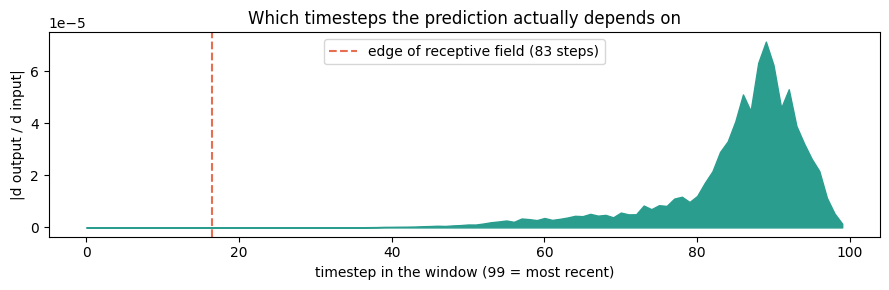

In [4]:
probe = torch.randn(1, 100, 40, requires_grad=True)
model(probe).sum().backward()
influence = probe.grad[0].abs().sum(dim=1).numpy()

reachable = np.flatnonzero(influence)
print(f"timesteps with non-zero gradient : {len(reachable)}")
print(f"earliest influential timestep    : {int(reachable.min())} (of 0..99)")
print(f"measured receptive field         : {100 - int(reachable.min())}")
print(f"claimed by model.receptive_field(): {model.receptive_field()}")

figure, axis = plt.subplots(figsize=(9, 3))
axis.fill_between(range(100), influence, color="#2a9d8f")
axis.axvline(int(reachable.min()) - 0.5, color="#e76f51", linestyle="--",
             label=f"edge of receptive field ({model.receptive_field()} steps)")
axis.set_xlabel("timestep in the window (99 = most recent)")
axis.set_ylabel("|d output / d input|")
axis.set_title("Which timesteps the prediction actually depends on")
axis.legend()
plt.tight_layout()
plt.show()

### The gradient agrees with the arithmetic, and the shape is informative

Measured field 83, claimed 83. Two things follow.

**The first 17 timesteps of every window are dead weight.** The model cannot
see them. We feed 100 and use 83 — worth knowing, and worth revisiting if a
later stage wants either a cheaper input or a deeper stack.

**Influence rises sharply toward the present.** The most recent timesteps
dominate the gradient, which is what a microstructure model *should* look
like: the book as it is right now matters far more than the book eighty
events ago. Stage 5 measures the signal's half-life directly; if that turns
out to exceed 83 events, this architecture needs another dilation level and
that decision gets made in writing.

## 4. Why a TCN, and why not a transformer

**Not an LSTM**, which is the canonical DeepLOB choice and would work fine on
accuracy. Three reasons, in the order they matter for this project:

1. *Inference latency is the deliverable.* A recurrent step is sequentially
   dependent — T timesteps means T dependent matrix multiplies. A dilated
   convolution stack is a fixed sequence of GEMMs with a statically known
   access pattern, which is what makes the Stage 7 C++ path tractable.
2. *Incremental inference.* Every layer here is causal, so a new tick only
   needs the new column: state lives in a ring buffer and advances by one
   instead of recomputing a 100×40 forward pass. That is the difference
   between microseconds and milliseconds.
3. *Determinism and parity.* Reproducing convolution arithmetic between
   PyTorch and hand-written C++ is tractable; reproducing cuDNN's fused
   recurrent kernels is not, and the Stage 7 parity test is mandatory.

**Not a transformer.** At 100 timesteps and this parameter budget, attention
buys nothing and costs exactly what we care about: it is O(T²) in time and
memory where the dilated stack is O(T), it has no incremental form (every new
tick re-attends over the whole window, so the ring-buffer trick disappears),
and a 100-step window with strong local structure is precisely the regime
where convolutions already capture the dependencies. We care about the p99,
and attention's p99 is worse for no accuracy we could point to.

**One honest caveat on causality.** `BatchNorm` computes its statistics over
batch *and* time, so during training the activation at step t is influenced by
the whole window. That is not look-ahead — the window already stops at t and
the label looks forward from t — and at inference the layer uses frozen
running statistics, so the deployed model is strictly causal. The distinction
is worth knowing before someone asks.

## 5. Overfitting one batch on purpose

Before asking whether a model *generalises*, ask whether it can learn at all.

A model that cannot fit 32 samples it sees hundreds of times has a bug — a
detached gradient, a transposed axis, a label misalignment — and no amount of
tuning on the real dataset will reveal which. Overfitting on purpose separates
"the plumbing is broken" from "the problem is hard", and those two failures
look identical on a learning curve.

In [5]:
torch.manual_seed(0)
demo = build_model(seed=0)
demo_inputs = torch.randn(32, 100, 40)
demo_targets = torch.randint(0, 3, (32,))
optimiser = torch.optim.AdamW(demo.parameters(), lr=3e-3)
loss_function = torch.nn.CrossEntropyLoss()

losses, accuracies = [], []
demo.train()
for step in range(200):
    optimiser.zero_grad()
    logits = demo(demo_inputs)
    loss = loss_function(logits, demo_targets)
    loss.backward()
    optimiser.step()
    losses.append(float(loss))
    accuracies.append(float((logits.argmax(1) == demo_targets).float().mean()))
    if accuracies[-1] == 1.0:
        break
print(f"reached 100% on 32 random samples after {len(losses)} steps (loss {losses[-1]:.4f})")

reached 100% on 32 random samples after 4 steps (loss 0.1213)


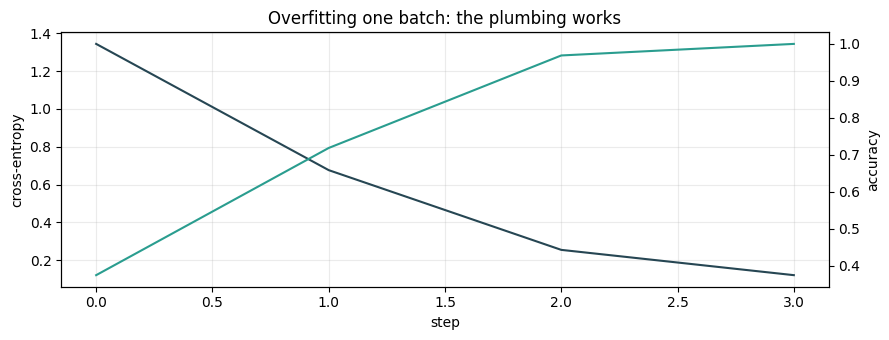

In [6]:
figure, axis = plt.subplots(figsize=(9, 3.5))
axis.plot(losses, color="#264653", label="loss")
axis.set_xlabel("step")
axis.set_ylabel("cross-entropy")
accuracy_axis = axis.twinx()
accuracy_axis.plot(accuracies, color="#2a9d8f", label="accuracy")
accuracy_axis.set_ylabel("accuracy")
axis.set_title("Overfitting one batch: the plumbing works")
axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### It memorises random labels, so the gradients flow

The targets here are **random** — there is no pattern to find. Reaching 100%
therefore proves exactly one thing, which is the thing we wanted: every
parameter receives gradient and the optimiser can move the model wherever the
loss demands. If this curve had plateaued, nothing further in this notebook
would have been worth running.

It converges in a handful of steps, which is faster than it looks and worth
one caveat before someone else raises it: `BatchNorm` is in training mode, so
the network can partly separate samples using *batch* statistics rather than
by learning each input. That makes this an easier test than it appears — but
it does not weaken the conclusion, because the failure it is designed to catch
(no gradient reaching some parameter) would still fail it. Note also that
accuracy hits 100% while the loss is still ~0.12: the argmax is right before
the model is confident.

## 6. The data, and where early stopping is allowed to look

Stage 3 produced 37,165 labelled samples across three capture sessions, with a
199-sample embargo (`W + k - 1`) between any train and test block.

One subtlety this stage had to fix. The obvious setup — early-stop on the
fold's test block and then report that same block — is a quiet form of fitting
to the test set: the stopping epoch is chosen by looking at the number being
reported, so the score is a maximum over ~40 peeks rather than an unbiased
estimate. So the last 15% of the *training* block becomes a validation set,
with its own embargo, and the test block is not touched until the run is over.

In [7]:
from ml.dataset import build_sample_index, describe_sessions, load_sessions
from ml.labels import DEFAULT_SMOOTHING_K
from ml.splits import required_embargo, walk_forward_splits
from ml.train import carve_validation

tapes = sorted(glob.glob(str(REPO_ROOT / "data" / "stage3" / "*.tape")))
if tapes:
    sessions = load_sessions(tapes)
    index = build_sample_index(sessions)
    print(describe_sessions(sessions, index))
    embargo = required_embargo(100, DEFAULT_SMOOTHING_K)
    split = walk_forward_splits(len(index), 3, embargo)[-1]
    fit_positions, validation_positions = carve_validation(split, embargo)
    print(f"\nembargo {embargo} samples  (feature window 100 + label horizon {DEFAULT_SMOOTHING_K} - 1)")
    print(f"fit        {len(fit_positions):>7,}  [{fit_positions[0]:>6,} .. {fit_positions[-1]:>6,}]")
    print(f"validation {len(validation_positions):>7,}  [{validation_positions[0]:>6,} .. "
          f"{validation_positions[-1]:>6,}]   <- early stopping looks here")
    print(f"test       {split.test_size:>7,}  [{split.test_start:>6,} .. {split.test_end:>6,}]"
          f"   <- untouched until the end")
else:
    print("no tapes under data/stage3/ — run data_engine.capture to reproduce the training numbers")

session                                      rows   usable    down    flat      up
btcusdt_20260727T191845_898907Z            14,109   13,411   0.337   0.330   0.333
btcusdt_20260727T192658_360768Z            19,614   18,916   0.239   0.359   0.402
btcusdt_20260727T193712_001784Z             5,536    4,838   0.394   0.267   0.339
TOTAL                                               37,165   0.295   0.337   0.369

embargo 199 samples  (feature window 100 + label horizon 100 - 1)
fit         23,324  [     0 .. 23,323]
validation   4,151  [23,523 .. 27,673]   <- early stopping looks here
test         9,292  [27,873 .. 37,164]   <- untouched until the end


### Three blocks, two gaps

Every boundary in that listing has an embargo behind it. The cost is about
400 discarded samples out of 37,165 — around 1% — and it buys a number that
cannot be attacked on either of the two grounds this stage is exposed to:
train/test overlap, and stopping-epoch selection.

## 7. The baselines

A deep model reported without a baseline is not a result. Three of them, in
increasing order of how much they should worry us — computed by
`benchmarks/bench_baselines.py` on exactly the same split.

In [8]:
baseline_files = sorted(glob.glob(str(REPO_ROOT / "benchmarks" / "baselines_*.json")))
baselines = json.loads(Path(baseline_files[-1]).read_text()) if baseline_files else None
if baselines:
    results = baselines["results"]
    print(f"from {Path(baseline_files[-1]).name}\n")
    print(f"{'baseline':<28} {'macro-F1':>9} {'accuracy':>9}  {'parameters':>11}")
    print(f"{'majority class':<28} {results['majority_class']['macro_f1']:>9.4f} "
          f"{results['majority_class']['accuracy']:>9.4f}  {0:>11}")
    print(f"{'queue imbalance + dead zone':<28} {results['queue_imbalance_rule']['macro_f1']:>9.4f} "
          f"{results['queue_imbalance_rule']['accuracy']:>9.4f}  {1:>11}")
    print(f"{'logistic, last snapshot':<28} {results['logistic_regression']['macro_f1']:>9.4f} "
          f"{results['logistic_regression']['accuracy']:>9.4f}  "
          f"{results['logistic_regression']['parameters']:>11}")
else:
    print("run: python benchmarks/bench_baselines.py --tapes 'data/stage3/*.tape'")

from baselines_20260728T102430Z.json

baseline                      macro-F1  accuracy   parameters
majority class                  0.1657    0.3308            0
queue imbalance + dead zone     0.3950    0.3974            1
logistic, last snapshot         0.5317    0.5298          123


### The logistic regression is uncomfortably good

Majority class at 0.166 is the floor — a three-class macro-F1 of about 1/6, as
expected. The queue-imbalance rule more than doubles it with a single
threshold, which is a useful reminder of how much of this problem is just
"which side has more size resting".

But the number that matters is the third one: **logistic regression on the
final snapshot alone scores 0.532 macro-F1 with 123 parameters and no history
whatsoever.** That is the bar. Whatever the deep model scores, the honest
question is not "did it beat the majority class" — it is "what did 100
timesteps and 320,000 parameters buy over 40 numbers and 123?"

Setting this up before training was deliberate. A baseline computed
afterwards, once you know what you need to beat, is not really a baseline.

## 8. Training

AdamW, cosine schedule with warmup, class-weighted cross-entropy, early
stopping on validation macro-F1. The curves below are read from the CSV the
training run saved, not regenerated.

One decision the curves make visible: **early stopping is on macro-F1, not on
loss.** Watch what validation loss does.

In [9]:
runs = sorted(glob.glob(str(REPO_ROOT / "benchmarks" / "train_ours_btcusdt_*.json")))
if runs:
    run = json.loads(Path(runs[-1]).read_text())
    history_path = REPO_ROOT / "benchmarks" / run["artefacts"]["csv"]
    history = np.genfromtxt(history_path, delimiter=",", names=True)
    print(f"from {Path(runs[-1]).name}")
    print(f"  device        : {run['machine'].get('gpu', run['machine']['device'])}")
    print(f"  epochs run    : {run['result']['epochs_run']} (best at {run['result']['best_epoch']}, "
          f"early stop: {run['result']['stopped_early']})")
    print(f"  validation F1 : {run['result']['validation_macro_f1']:.4f}")
    print(f"  TEST macro-F1 : {run['result']['test_macro_f1']:.4f}")
    print(f"  test accuracy : {run['result']['test_accuracy']:.4f}")
    print(f"  per-class F1  : " + ", ".join(f"{n} {v:.3f}" for n, v
                                            in zip(("down", "flat", "up"), run["result"]["per_class_f1"])))
else:
    run, history = None, None
    print("no training run found — run: python -m ml.train --tapes 'data/stage3/*.tape' --epochs 40")

from train_ours_btcusdt_20260728T102758Z.json
  device        : NVIDIA GeForce RTX 2050
  epochs run    : 17 (best at 8, early stop: True)
  validation F1 : 0.6569
  TEST macro-F1 : 0.5493
  test accuracy : 0.5506
  per-class F1  : down 0.601, flat 0.407, up 0.640


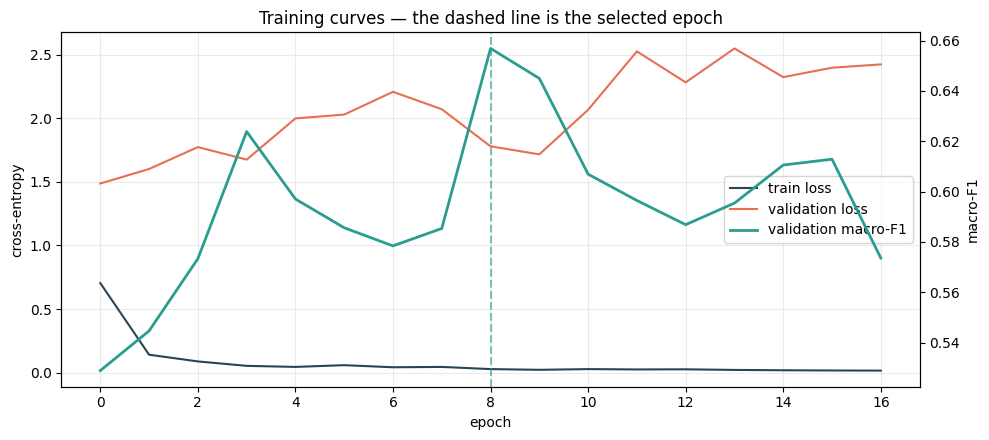

In [10]:
if history is not None:
    figure, loss_axis = plt.subplots(figsize=(10, 4.5))
    loss_axis.plot(history["epoch"], history["train_loss"], color="#264653", label="train loss")
    loss_axis.plot(history["epoch"], history["validation_loss"], color="#e76f51", label="validation loss")
    loss_axis.set_xlabel("epoch")
    loss_axis.set_ylabel("cross-entropy")
    loss_axis.grid(alpha=0.25)
    score_axis = loss_axis.twinx()
    score_axis.plot(history["epoch"], history["validation_macro_f1"], color="#2a9d8f",
                    linewidth=2, label="validation macro-F1")
    score_axis.axvline(run["result"]["best_epoch"], color="#2a9d8f", linestyle="--", alpha=0.6)
    score_axis.set_ylabel("macro-F1")
    handles = loss_axis.get_legend_handles_labels()[0] + score_axis.get_legend_handles_labels()[0]
    labels = loss_axis.get_legend_handles_labels()[1] + score_axis.get_legend_handles_labels()[1]
    loss_axis.legend(handles, labels, loc="center right")
    loss_axis.set_title("Training curves — the dashed line is the selected epoch")
    plt.tight_layout()
    plt.show()

### Validation loss goes up while macro-F1 goes up

This is the single most instructive plot in the notebook, and it vindicates a
design decision that would otherwise look like a detail.

Training loss collapses almost immediately — the model memorises 23,000
overlapping windows within a few epochs. Validation *loss* rises steadily from
there, which is the textbook picture of overfitting, and a run that early-
stopped on loss would have quit around epoch 1.

But validation **macro-F1 keeps improving well past that point.** The two
metrics disagree because cross-entropy punishes confident mistakes, and a
model growing more confident about the majority class gets worse loss while
getting better at the minority classes — which is exactly what macro-F1
rewards and what we actually want. Stopping on the metric we report is not
pedantry; here it is worth several points of F1.

## 9. FI-2010, and the results table

Everything so far is measured on data we captured ourselves, which makes it
honest and incomparable — nobody else has our tape. FI-2010 is the standard
public benchmark for this exact task, so training the same architecture on it
gives one number a reader can place against published work.

Source: Ntakaris et al. (2018),
<https://etsin.fairdata.fi/dataset/73eb48d7-4dbc-4a10-a52a-da745b47a649>,
using the `NoAuction_DecPre` preprocessing and the 40 raw LOB features — the
same input published architectures use.

**Published results at the same horizon**, from DeepLOB (Zhang, Zohren &
Roberts, [arXiv:1808.03668](https://arxiv.org/abs/1808.03668)) Table II,
Setup 2 — which is the same division we use, 7 training days and the final 3
days as test:

| Model | F1 % | Accuracy % |
|---|---|---|
| CNN-I | 55.21 | — |
| LSTM | 66.33 | — |
| B(TABL) | 69.20 | 78.91 |
| C(TABL) | 77.63 | 84.70 |
| DeepLOB | **83.40** | 84.47 |

**Read our number against these with three caveats, not without them.** The
published runs use the `Zscore` normalisation where we use `DecPre`; they
train far longer than the budget used here; and the paper's F1 averaging
convention may differ from our macro average. Our figure is a floor on what
this architecture can do on this data, not a like-for-like ranking.

In [11]:
fi_runs = sorted(glob.glob(str(REPO_ROOT / "benchmarks" / "train_fi2010_*.json")))
fi_run = json.loads(Path(fi_runs[-1]).read_text()) if fi_runs else None

rows = []
if baselines:
    got = baselines["results"]
    rows.append(("majority class", "ours (BTCUSDT)", 0, got["majority_class"]["macro_f1"]))
    rows.append(("queue imbalance rule", "ours (BTCUSDT)", 1, got["queue_imbalance_rule"]["macro_f1"]))
    logistic = got["logistic_regression"]
    rows.append(("logistic, last snapshot", "ours (BTCUSDT)", logistic["parameters"], logistic["macro_f1"]))
if run:
    rows.append(("CNN+TCN (this project)", "ours (BTCUSDT)",
                 run["model"]["parameters"], run["result"]["test_macro_f1"]))
if fi_run:
    rows.append(("CNN+TCN (this project)", f"FI-2010 h={fi_run['data']['horizon']}",
                 fi_run["model"]["parameters"], fi_run["result"]["test_macro_f1"]))

print(f"{'model':<26} {'dataset':<18} {'parameters':>11} {'macro-F1':>9}")
for name, dataset, parameters, score in rows:
    print(f"{name:<26} {dataset:<18} {parameters:>11,} {score:>9.4f}")

model                      dataset             parameters  macro-F1
majority class             ours (BTCUSDT)               0    0.1657
queue imbalance rule       ours (BTCUSDT)               1    0.3950
logistic, last snapshot    ours (BTCUSDT)             123    0.5317
CNN+TCN (this project)     ours (BTCUSDT)         319,715    0.5493
CNN+TCN (this project)     FI-2010 h=10           319,715    0.7515


And the same architecture placed against the published FI-2010 numbers.

In [12]:
published = (("CNN-I", 55.21), ("LSTM", 66.33), ("B(TABL)", 69.20), ("C(TABL)", 77.63), ("DeepLOB", 83.40))
if fi_run:
    print("FI-2010, horizon 10 — F1 %  (published rows: DeepLOB Table II, Setup 2)")
    for name, score in published:
        print(f"  {name:<10} {score:>6.2f}")
    print(f"  {'ours':<10} {fi_run['result']['test_macro_f1'] * 100:>6.2f}   <- see the caveats above")
    print(f"\nours trained {fi_run['result']['epochs_run']} epochs on {fi_run['data']['sessions'][0]}")
else:
    print("FI-2010 row missing — run: python -m ml.train --fi2010 data/fi2010 --tag fi2010")

FI-2010, horizon 10 — F1 %  (published rows: DeepLOB Table II, Setup 2)
  CNN-I       55.21
  LSTM        66.33
  B(TABL)     69.20
  C(TABL)     77.63
  DeepLOB     83.40
  ours        75.15   <- see the caveats above

ours trained 14 epochs on Train_Dst_NoAuction_DecPre_CF_7


## Interview checkpoint

**1. Walk me through the convolutional front end. Why those three stages?**
The 40-column feature axis is collapsed in three steps that each mean
something: a stride-2 kernel of width 2 fuses each (price, size) pair into
"what is resting at this level on this side"; the same again fuses the bid
summary against the ask summary, which is per-level imbalance — the strongest
cheap microstructure feature; and a full-width kernel fuses the ten levels
into whole-book shape. Between each, two causal width-4 convolutions look
along time, because mixing levels and mixing time are different operations and
separating them keeps every layer explainable.

**2. Why a TCN rather than an LSTM, given the literature uses LSTMs?**
Because the deliverable is inference latency, not just accuracy. A recurrent
step is sequentially dependent, so T timesteps is T dependent matmuls; a
dilated causal stack is a fixed sequence of GEMMs with a known access pattern,
which is what makes Stage 7's hand-written C++ path tractable and what allows
O(1) incremental updates from a ring buffer instead of a full 100×40 forward
pass per tick. There is also a parity argument: reproducing convolution
arithmetic between PyTorch and C++ is doable, reproducing fused cuDNN
recurrent kernels is not.

**3. What is the receptive field, and how do you know?**
83 of the 100 timesteps, and I read it off the computation graph rather than
trusting the arithmetic — differentiate the output with respect to the input
and see which timesteps have non-zero gradient. It comes from
`3 × 2 × (4−1)` in the front end, `+4` from the widest inception branch, and
`2 × (3−1) × (1+2+4+8) = 60` from the dilated stack. Seventeen timesteps of
every window are outside it, which is worth knowing and worth revisiting if
Stage 5's measured signal half-life turns out to be longer.

**4. Your validation loss increases while you keep training. Why is that not a bug?**
Because loss and macro-F1 disagree on this problem, and macro-F1 is what we
report. Cross-entropy punishes confident errors, so a model becoming more
confident about the majority class gets worse loss while getting better at the
minority classes — which is what macro-F1 rewards and what a trading signal
actually needs. Early stopping therefore watches macro-F1; stopping on loss
would have quit around epoch 1 and cost several points of F1.

**5. Logistic regression on one snapshot gets 0.53. What did the deep model buy?**
That is the right question and the reason the baseline was computed before
training rather than after. Most of the achievable score on this task comes
from the instantaneous shape of the book, so the honest measure of the
architecture is the margin over 123 parameters with no history — not the
margin over the majority class. Whatever that margin is, it is also the thing
Stages 6 and 7 are about to spend weeks compressing and hand-rolling, so
knowing its size before starting is the point.